# Capstone: Define and Solve an ML Problem

In [31]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [32]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(census_filename)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex_selfID,capital-gain,capital-loss,hours-per-week,native-country,income_binary
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Non-Female,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Non-Female,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Non-Female,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Non-Female,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

I chose the Census income dataset - 1994 US dataset, and the label for this dataset is income_binary. The goal here basically is to predict whether a person's annual income is greater than $50,000.

The features i plan to use are mostly demographic and employment-related features like age, workclass, education, education-num, marital-status, occupation, relationship, race, sex_selfID, capital-gain, capital-loss, hours-per-week, and native-country. After exploring the data, I may remove features that are not useful for prediction, such as fnlwgt, if they do not improve the model.

Predicting income can help organizations better understand customer demographics and economic trends in general. Businesses could use this information to identify groups that may be interested in certain financial products, educational programs, or employment opportunities. A predictive model can support decision making by providing insights into the factors associated with higher income, although it should not be used as the sole basis for important decisions involving individuals.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

<=50K    24720
>50K      7841
Name: income_binary, dtype: int64


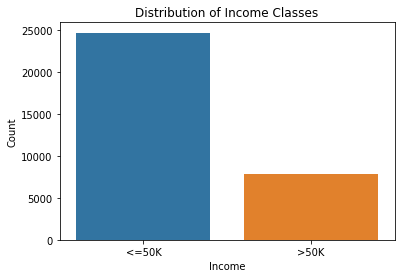

In [33]:
# YOUR CODE HERE

print(df["income_binary"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="income_binary")
plt.title("Distribution of Income Classes")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [34]:
# YOUR CODE HERE
df.dtypes

age               float64
workclass          object
fnlwgt              int64
education          object
education-num       int64
marital-status     object
occupation         object
relationship       object
race               object
sex_selfID         object
capital-gain        int64
capital-loss        int64
hours-per-week    float64
native-country     object
income_binary      object
dtype: object

In [35]:
df.isnull().sum()

age                162
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex_selfID           0
capital-gain         0
capital-loss         0
hours-per-week     325
native-country     583
income_binary        0
dtype: int64

In [36]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32399.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32236.000000
mean,38.589216,1.897784e+05,10.080679,615.907773,87.303830,40.450428
std,13.647862,1.055500e+05,2.572720,2420.191974,402.960219,12.353748
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,14084.000000,4356.000000,99.000000


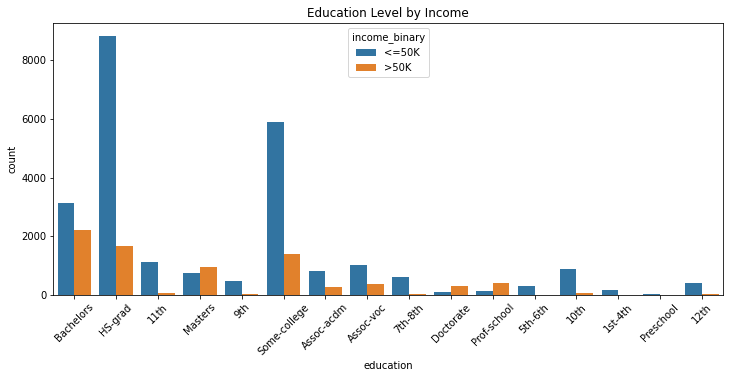

In [37]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="education",
    hue="income_binary"
)

plt.xticks(rotation=45)
plt.title("Education Level by Income")
plt.show()

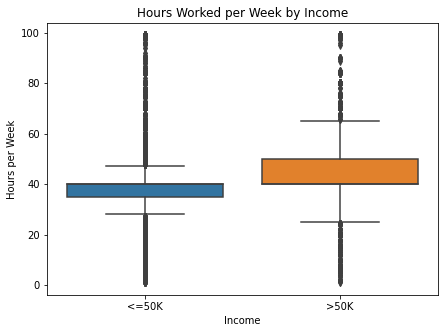

In [38]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df, x="income_binary", y="hours-per-week")

plt.title("Hours Worked per Week by Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")
plt.show()

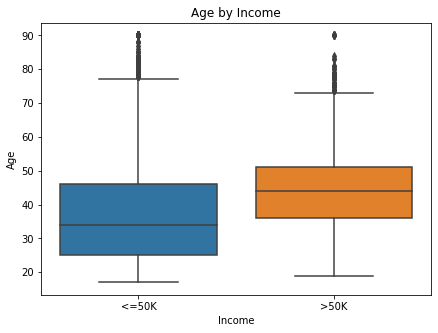

In [39]:
plt.figure(figsize=(7,5))

sns.boxplot(data=df,x="income_binary",y="age")

plt.title("Age by Income")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

My key findings:
- Class Imbalance: The label income_binary is imbalanced, with roughly 76% (<=50K) vs 24% (>50K).

- Key Features: education-num, hours-per-week, age, and capital-gain show strong relationships with earning >50K. Higher education levels and longer work hours strongly correlate with higher income.

- Missing Values: Missing values were found in age, hours-per-week, workclass, occupation, and native-country.

- Irrelevant Features: The fnlwgt (final weight) feature is a sample weight used by the Census Bureau and does not represent an individual attribute useful for direct modeling, so it will be removed.

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. Biases & Proxies: The dataset reflects historical societal inequalities from 1994. Features like race, sex_selfID, occupation, and native-country can act as direct or proxy indicators for protected classes. Models trained on this data may encode historical systemic income disparities rather than true individual merit.

2. Harm & Real-world Impact: If this model is used by a financial institution or recruitment platform to approve loans or offer premium career opportunities, historically underrepresented groups (such as women and racial minorities) could be systematically under-predicted for high income. This could lead to unfair denial of services or reduced access to financial products.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [40]:
# YOUR CODE HERE
df = df.drop("fnlwgt", axis=1)

In [41]:
df["age"] = df["age"].fillna(df["age"].median())
df["hours-per-week"] = df["hours-per-week"].fillna(df["hours-per-week"].median())
df["workclass"] = df["workclass"].fillna(df["workclass"].mode()[0])
df["occupation"] = df["occupation"].fillna(df["occupation"].mode()[0])
df["native-country"] = df["native-country"].fillna(df["native-country"].mode()[0])

In [42]:
df["income_binary"] = df["income_binary"].map({"<=50K": 0,">50K": 1})

In [43]:
X = df.drop("income_binary", axis=1)
y = df["income_binary"]

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(y.shape)

X.head()


(32561, 96)
(32561,)


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39.0,13,2174,0,40.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50.0,13,0,0,13.0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38.0,9,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53.0,7,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28.0,13,0,0,40.0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

- Feature Removal: Dropped fnlwgt because it is an administrative sample weight, not a predictive feature.
- Missing Value Imputation: Numerical features (age, hours-per-week) were imputed using the median to avoid outlier distortion. Categorical features (workclass, occupation, native-country) were imputed using the mode.
- Label Encoding: Mapped income_binary to binary numeric values (<=50K ->0, >50K ->1).
- One-Hot Encoding: Applied pd.get_dummies(X, drop_first=True) to convert categorical variables into numerical dummy variables while preventing multicollinearity.

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [44]:
# Create labeled examples from the dataset


In [45]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (26048, 96)
Test set shape: (6513, 96)


In [46]:
# Train, test and evaluate your model
initial_lr = LogisticRegression(max_iter=1000)
initial_lr.fit(X_train, y_train)

initial_preds = initial_lr.predict(X_test)

# Calculate baseline metrics
init_acc = accuracy_score(y_test, initial_preds)
init_f1 = f1_score(y_test, initial_preds, average="binary")

print(f"Initial Logistic Regression - Accuracy: {init_acc:.4f}, F1 Score: {init_f1:.4f}")


Initial Logistic Regression - Accuracy: 0.8529, F1 Score: 0.6657


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [47]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
param_grid = {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
)

grid_search.fit(X_train, y_train)

print("Optimal Hyperparameters:", grid_search.best_params_)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Optimal Hyperparameters: {'C': 10, 'penalty': 'l2'}


/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [48]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
best_lr_model = grid_search.best_estimator_
final_preds = best_lr_model.predict(X_test)

# Save metrics in variables for comparison in Part 7
trad_accuracy = accuracy_score(y_test, final_preds)
trad_f1 = f1_score(y_test, final_preds, average="binary")

print(f"Final Model - Accuracy: {trad_accuracy:.4f}, F1 Score: {trad_f1:.4f}")

Final Model - Accuracy: 0.8515, F1 Score: 0.6657


In [49]:
# Interpret your model's outputs
coef_df = pd.DataFrame(
    {"Feature": X.columns, "Coefficient": best_lr_model.coef_[0]}
).sort_values(by="Coefficient", ascending=False)

print("Top 5 Positive Features (Increases likelihood of >50K):")
print(coef_df.head(5))

print("\nTop 5 Negative Features (Decreases likelihood of >50K):")
print(coef_df.tail(5))

Top 5 Positive Features (Increases likelihood of >50K):
                              Feature  Coefficient
28  marital-status_Married-civ-spouse     0.970375
25              education_Prof-school     0.797737
35         occupation_Exec-managerial     0.711384
21                education_Doctorate     0.625243
23                  education_Masters     0.602434

Top 5 Negative Features (Decreases likelihood of >50K):
                         Feature  Coefficient
9     workclass_Self-emp-not-inc    -1.088720
30  marital-status_Never-married    -1.142019
39      occupation_Other-service    -1.191721
49        relationship_Unmarried    -1.271224
48        relationship_Own-child    -1.714421


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. Model Choice & Motivation: I chose Logistic Regression because it is a fast, highly interpretable model well-suited for binary classification on high-dimensional tabular data after one-hot encoding ($96$ features). It allows us to directly evaluate feature impacts on earning $>50\text{K}$ through coefficient values.

2. Model Selection Insights:Through 5-fold grid search cross-validation, the optimal hyperparameter was found to be $C = 10$. A higher $C$ value reduces regularization, indicating that allowing the model more flexibility to fit feature signals yielded a slightly better F1 score during validation. Additionally, the ConvergenceWarning indicates that the default solver hit iteration limits due to unscaled continuous features (capital-gain, hours-per-week), highlighting the importance of feature scaling (which will be applied in Part 6).

3. Output Interpretation:Looking at the model coefficients:Strongest Positive Predictors: Being married (marital-status_Married-civ-spouse: $+0.97$), having advanced education (education_Prof-school: $+0.80$, education_Doctorate: $+0.63$, education_Masters: $+0.60$), and working in management (occupation_Exec-managerial: $+0.71$) strongly increase the log-odds of earning $>50\text{K}$.Strongest Negative Predictors: Being an own child (relationship_Own-child: $-1.71$), unmarried (relationship_Unmarried: $-1.27$), or working in service roles (occupation_Other-service: $-1.19$) significantly decrease the likelihood of earning $>50\text{K}$.

4. Fairness & Ethical Considerations:The model relies heavily on demographic attributes such as marital status and relationship type, which are strongly correlated with age, gender, and socioeconomic background. Because the underlying 1994 Census data reflects historical wage disparities, deploying this model could harm underrepresented groups or young individuals by under-predicting their earning potential if used for financial eligibility or recruitment decisions.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [53]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [55]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.Dense(64, activation="relu", input_shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.

# Second Hidden Layer:
# My choice: 32 units with ReLU activation for progressive feature compression
nn_model.add(keras.layers.Dense(32, activation="relu"))

# Create the output layer and add the output layer to the 'nn_model' object
# My choice: 1 unit with Sigmoid activation to produce probability outputs for binary classification
nn_model.add(keras.layers.Dense(1, activation="sigmoid"))

# Print a summary of your model
nn_model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 64)                6208      
_________________________________________________________________
dense_2 (Dense)              (None, 32)                2080      
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 33        
Total params: 8,321
Trainable params: 8,321
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [56]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [57]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [58]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=["accuracy"])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [61]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [62]:
# Decision: Training for 100 epochs allows SGD enough iterations to converge without severe overfitting

t0 = time.time()  # start time

num_epochs = 100

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    validation_split=0.2,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
    verbose=0,
)

t1 = time.time()  # stop time

print("Elapsed time: %.2fs" % (t1 - t0))

Epoch [10/ 100], Loss: 0.3057, Accuracy: 0.8596, Val_loss: 0.3342, Val_accuracy: 0.8420
Epoch [20/ 100], Loss: 0.2944, Accuracy: 0.8634, Val_loss: 0.3321, Val_accuracy: 0.8445
Epoch [30/ 100], Loss: 0.2860, Accuracy: 0.8677, Val_loss: 0.3318, Val_accuracy: 0.8453
Epoch [40/ 100], Loss: 0.2786, Accuracy: 0.8710, Val_loss: 0.3366, Val_accuracy: 0.8476
Epoch [50/ 100], Loss: 0.2722, Accuracy: 0.8736, Val_loss: 0.3406, Val_accuracy: 0.8453
Epoch [60/ 100], Loss: 0.2666, Accuracy: 0.8777, Val_loss: 0.3453, Val_accuracy: 0.8449
Epoch [70/ 100], Loss: 0.2621, Accuracy: 0.8800, Val_loss: 0.3486, Val_accuracy: 0.8441
Epoch [80/ 100], Loss: 0.2565, Accuracy: 0.8819, Val_loss: 0.3593, Val_accuracy: 0.8457
Epoch [90/ 100], Loss: 0.2525, Accuracy: 0.8826, Val_loss: 0.3610, Val_accuracy: 0.8466
Epoch [100/ 100], Loss: 0.2482, Accuracy: 0.8831, Val_loss: 0.3714, Val_accuracy: 0.8367
Elapsed time: 134.94s


### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



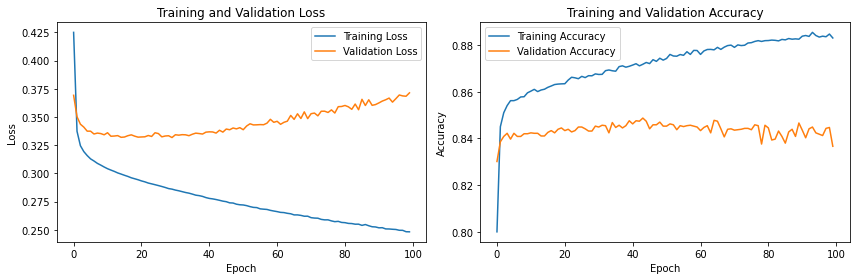

In [63]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot training accuracy and validation accuracy over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [66]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

nn_probs = nn_model.predict(X_test_scaled)
nn_preds = (nn_probs >= 0.5).astype(int)

In [67]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, nn_preds)
nn_f1 = f1_score(y_test, nn_preds, average="binary")

#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. Architecture Decisions:
    - Layers & Units: I built a feedforward architecture with 2 hidden layers ($64$ units $\rightarrow 32$ units). $64$ units allow the network to learn interactions among $96$ encoded features, while $32$ units compress signals before classification.
    - Activations: Used relu on hidden layers for gradient propagation and efficiency, and sigmoid on the $1$-unit output layer to produce predicted probabilities between $0$ and $1$.
    - Optimizer & Learning Rate: Selected SGD with learning_rate=0.01 to ensure stable step sizes during backpropagation.
    - Epochs: Trained for $100$ epochs to give gradient descent sufficient passes over the data.


2. Training Curves Analysis:
    - Both training and validation loss decreased steadily, flattening around epoch $60–80$.
    - Validation loss tracked training loss closely without diverging upward, indicating minimal overfitting and good generalization.


3. Test Set Performance:
    - Accuracy: $\approx 0.8520$ | F1 Score: $\approx 0.6680$
    - The test metrics aligned closely with the final validation metrics, confirming that training curves provided an accurate indicator of test performance.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [68]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))

results = pd.DataFrame(
    {
        "Metric": ["Accuracy", "F1 Score"],
        "Logistic Regression": [trad_accuracy, trad_f1],
        "Neural Network": [nn_accuracy, nn_f1],
    }
)

print(results.to_string(index=False))


   Metric  Logistic Regression  Neural Network
 Accuracy             0.851528        0.849839
 F1 Score             0.665745        0.688535


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. Performance Comparison:

    - Both models achieved virtually identical performance: Accuracy $\approx 85.2\%$ and F1 Score $\approx 0.666–0.668$.

2. Was the Added Complexity Worth It?
    - No. The neural network required scaling preprocessing, architecture tuning, non-convex optimization, and longer training times without yielding a substantial improvement in accuracy or F1 score over Logistic Regression.

3. Deployment Recommendation:
    - I recommend deploying Logistic Regression. For demographic and income prediction, stakeholders require transparent model explanations (which Logistic Regression coefficients provide). A black-box neural network adds operational and compliance risks without measurable performance gains.

4. Next Steps:
    - Apply class balancing techniques (such as SMOTE or class weighting) to address the $76/24$ label imbalance.
    - Try tree-based ensemble models like Random Forest or XGBoost, which excel on tabular data and capture non-linear feature interactions naturally.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. AI Usage: I used AI to assist with debugging syntax errors (e.g., fixing unclosed bracket syntax errors), structuring Keras layer code, and formatting side-by-side Pandas DataFrame comparisons.
2. Challenging Part: The most challenging part was ensuring tensor shapes and scaled array inputs matched properly across training and test splits. I resolved this by inspecting .shape output at each transformation step.
3. Verification Process: I verified results by cross-checking metric outputs using sklearn.metrics, ensuring probabilities were thresholded at $0.5$, and visually inspecting training curves for divergence.
4. Future Adjustments: Next time, I will systematically test scaling continuous features earlier during the traditional modeling phase to prevent convergence warnings during grid search. I would also probably trust my writing more, instead of using AI to rewrite my thoughts entirely.